# 🎨 Visualizaciones Avanzadas - Gases Refrigerantes

**KrioMetrics - Notebook 04**

Este notebook crea visualizaciones premium de nivel publicación para:

1. **Mapa de calor ambiental** - GWP vs ODP por tipo de compuesto
2. **Curvas P-T interactivas** - Presión de saturación vs temperatura
3. **Diagrama de burbujas** - Seguridad vs Sostenibilidad vs Adopción
4. **Radar charts** - Perfiles de propiedades por gas
5. **Timeline regulatorio** - Evolución histórica de regulaciones

---

In [1]:
# ============================================================
# BLOQUE 1: Setup
# ============================================================
import sys, os, warnings, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

plt.rcParams.update({
    'figure.facecolor': '#0E1117', 'axes.facecolor': '#1A1E2E',
    'axes.labelcolor': '#FAFAFA', 'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA', 'text.color': '#FAFAFA',
    'grid.color': '#2E3347', 'grid.linestyle': '--', 'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
})

# Cargar datos
DB_PATH = '../data/processed/refrigerants.db'
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query('SELECT * FROM dim_refrigerant', conn)
df_facts = pd.read_sql_query('SELECT * FROM fact_pressure_temperature', conn)
df_temp = pd.read_sql_query('SELECT * FROM dim_temperature', conn)
conn.close()

print(f'✅ Datos cargados: {len(df)} refrigerantes, {len(df_facts):,} puntos P-T')

✅ Datos cargados: 55 refrigerantes, 2,750 puntos P-T


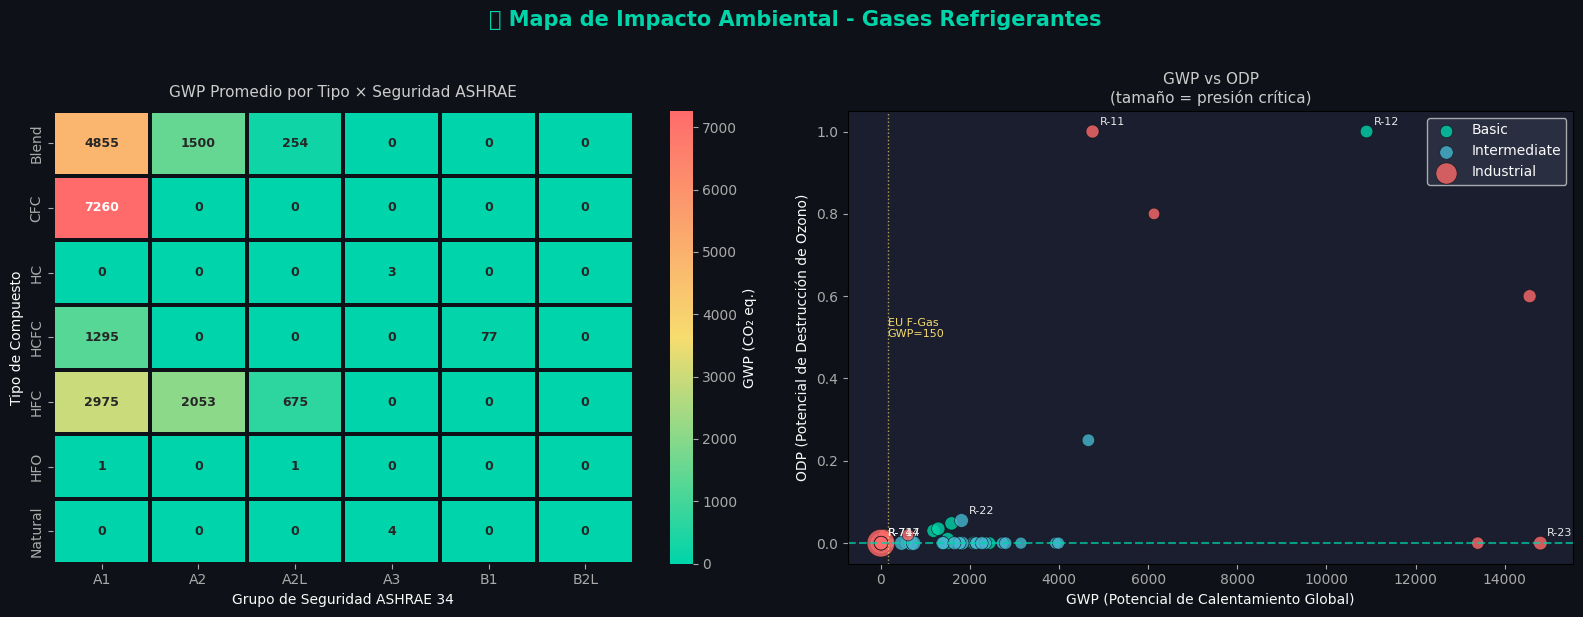

✅ Mapa ambiental guardado.


In [2]:
# ============================================================
# BLOQUE 2: Mapa de Calor Ambiental - GWP vs Tipo de Compuesto
# ============================================================
# Crear mapa de calor: filas = compound_type, columnas = safety_group, valores = GWP medio
pivot = df.pivot_table(values='gwp', index='compound_type', columns='safety_group', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🌍 Mapa de Impacto Ambiental - Gases Refrigerantes',
             fontsize=15, color='#00D4AA', fontweight='bold', y=1.02)

# Heatmap GWP por tipo y grupo de seguridad
eco_cmap = LinearSegmentedColormap.from_list(
    'eco', ['#00D4AA', '#F7DC6F', '#FF6B6B'], N=256
)

sns.heatmap(
    pivot.fillna(0), annot=True, fmt='.0f', cmap=eco_cmap,
    linewidths=1.5, linecolor='#0E1117',
    annot_kws={'size': 9, 'weight': 'bold'}, ax=axes[0],
    cbar_kws={'label': 'GWP (CO₂ eq.)'}
)
axes[0].set_title('GWP Promedio por Tipo × Seguridad ASHRAE', fontsize=11, color='#CCCCCC', pad=10)
axes[0].set_xlabel('Grupo de Seguridad ASHRAE 34', fontsize=10)
axes[0].set_ylabel('Tipo de Compuesto', fontsize=10)

# Scatter GWP vs ODP con tamaño proporcional a presión crítica
ax2 = axes[1]
cat_colors = {'Basic': '#00D4AA', 'Intermediate': '#45B7D1', 'Industrial': '#FF6B6B'}
type_markers = {'CFC': 'X', 'HCFC': 's', 'HFC': 'o', 'HC': '^',
                'Natural': 'D', 'HFO': 'P', 'Blend': '*'}

for cat, color in cat_colors.items():
    mask = df['category'] == cat
    subset = df[mask]
    sizes = np.clip(subset['critical_pressure_bar'] * 2, 20, 400)
    ax2.scatter(subset['gwp'], subset['odp'], c=color, s=sizes,
               alpha=0.8, edgecolors='#0E1117', linewidth=0.5, label=cat)

# Anotaciones
for _, row in df[df['ashrae_name'].isin(['R-11', 'R-12', 'R-22', 'R-717', 'R-744', 'R-23'])].iterrows():
    ax2.annotate(row['ashrae_name'], (row['gwp'], row['odp']),
                fontsize=8, color='#FFFFFF', alpha=0.9,
                xytext=(5, 5), textcoords='offset points')

ax2.set_title('GWP vs ODP\n(tamaño = presión crítica)', fontsize=11, color='#CCCCCC')
ax2.set_xlabel('GWP (Potencial de Calentamiento Global)', fontsize=10)
ax2.set_ylabel('ODP (Potencial de Destrucción de Ozono)', fontsize=10)
ax2.legend(facecolor='#2E3347', labelcolor='#FAFAFA')
ax2.axhline(0, color='#00D4AA', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.axvline(150, color='#F7DC6F', linewidth=1, linestyle=':', alpha=0.7)
ax2.text(155, max(df['odp'])*0.5, 'EU F-Gas\nGWP=150', color='#F7DC6F', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/environmental_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Mapa ambiental guardado.')

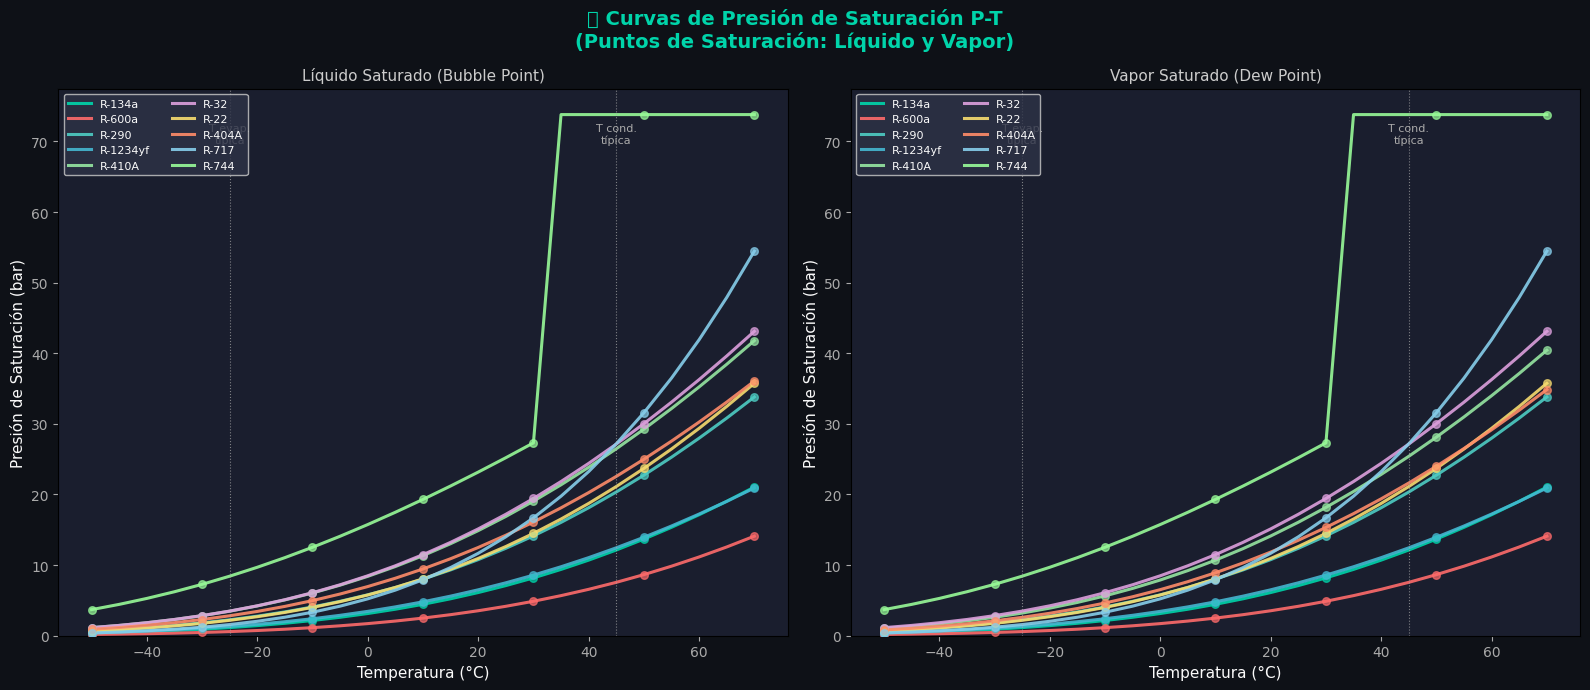

✅ Curvas P-T guardadas.


In [3]:
# ============================================================
# BLOQUE 3: Curvas P-T de Saturación (10 gases clave)
# ============================================================
# Seleccionar gases representativos de cada categoría
target_gases = ['R-134a', 'R-600a', 'R-290', 'R-1234yf',
                'R-410A', 'R-32', 'R-22', 'R-404A',
                'R-717', 'R-744']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('📈 Curvas de Presión de Saturación P-T\n(Puntos de Saturación: Líquido y Vapor)',
             fontsize=14, color='#00D4AA', fontweight='bold')

RICH_PALETTE = [
    '#00D4AA', '#FF6B6B', '#4ECDC4', '#45B7D1', '#96E6A1',
    '#DDA0DD', '#F7DC6F', '#FF8C69', '#87CEEB', '#98FB98'
]

for ax_idx, state_key in enumerate([1, 2]):
    ax = axes[ax_idx]
    state_label = 'Líquido Saturado (Bubble Point)' if state_key == 1 else 'Vapor Saturado (Dew Point)'
    
    for i, gas_name in enumerate(target_gases):
        gas_rows = df[df['ashrae_name'] == gas_name]
        if len(gas_rows) == 0:
            continue
        
        ref_key = gas_rows['refrigerant_key'].values[0]
        
        # Unir facts con temperaturas
        gas_facts = df_facts[
            (df_facts['refrigerant_key'] == ref_key) & 
            (df_facts['state_key'] == state_key)
        ].merge(df_temp, left_on='temperature_key', right_on='temperature_key')
        
        if len(gas_facts) == 0:
            continue
        
        gas_facts = gas_facts.sort_values('temperature_c')
        color = RICH_PALETTE[i % len(RICH_PALETTE)]
        
        ax.plot(
            gas_facts['temperature_c'], gas_facts['pressure_bar'],
            linewidth=2.2, color=color, alpha=0.9, label=gas_name
        )
        ax.scatter(
            gas_facts['temperature_c'].values[::4],
            gas_facts['pressure_bar'].values[::4],
            s=30, color=color, alpha=0.7, zorder=5
        )
    
    # Líneas de referencia operacionales
    ax.axvline(-25, color='#AAAAAA', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.axvline(45, color='#AAAAAA', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.text(-25, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 10, 'T evap.\ntípica',
            color='#AAAAAA', fontsize=8, ha='center')
    ax.text(45, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 10, 'T cond.\ntípica',
            color='#AAAAAA', fontsize=8, ha='center')
    
    ax.set_title(state_label, fontsize=11, color='#CCCCCC')
    ax.set_xlabel('Temperatura (°C)', fontsize=11)
    ax.set_ylabel('Presión de Saturación (bar)', fontsize=11)
    ax.legend(fontsize=8, facecolor='#2E3347', ncol=2, loc='upper left')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../data/processed/pt_saturation_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Curvas P-T guardadas.')

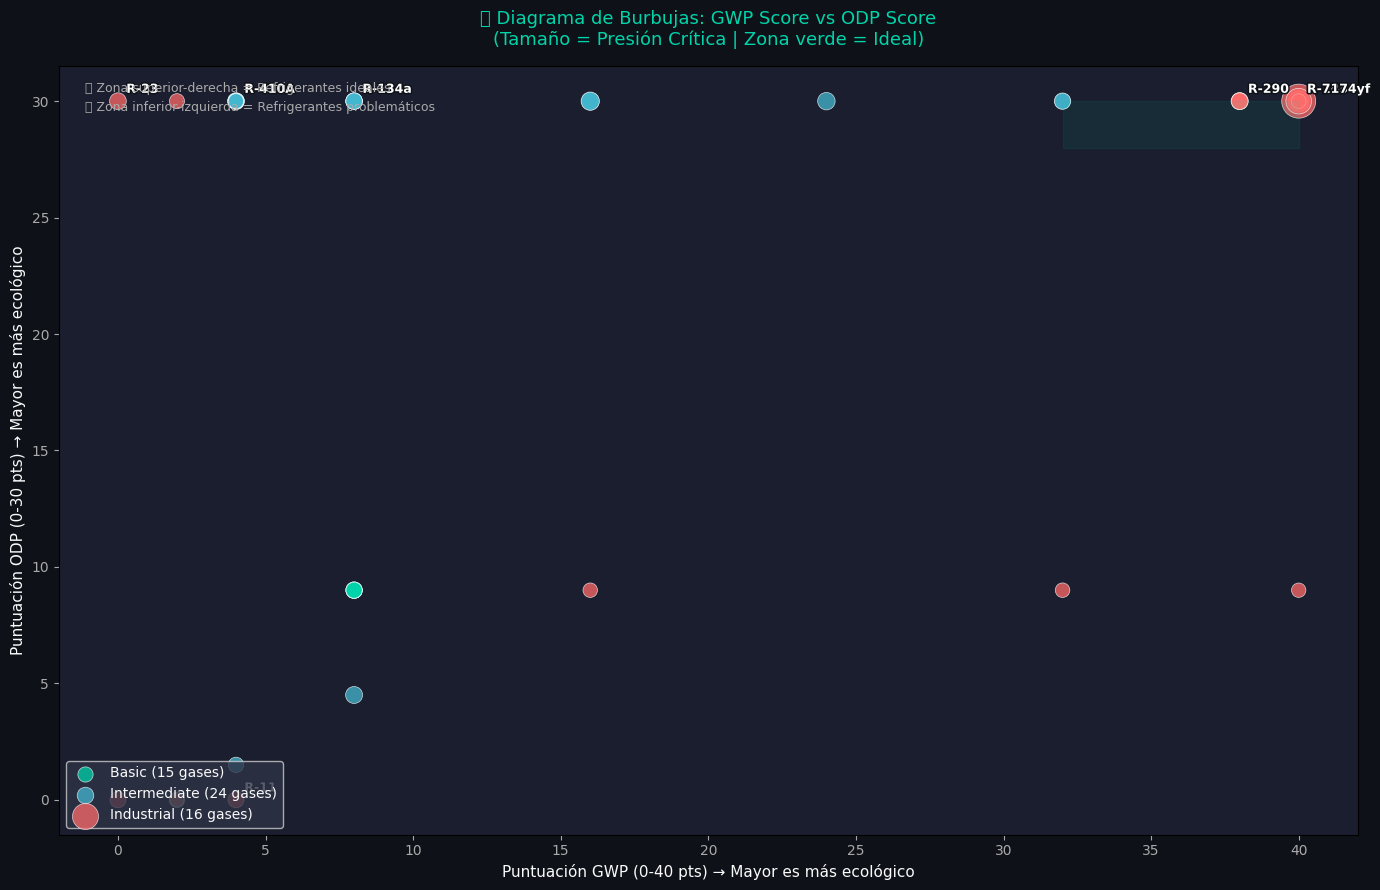

✅ Diagrama de burbujas guardado.


In [4]:
# ============================================================
# BLOQUE 4: Diagrama de Burbujas - Sostenibilidad
# ============================================================
sys.path.insert(0, os.path.abspath('..'))
from src.domain.sustainability import SustainabilityAnalyzer
from src.infrastructure.readers import RefrigerantDataReaderFactory

reader = RefrigerantDataReaderFactory.get_reader('fallback')
refrigerants = reader.read_refrigerants()
analyzer = SustainabilityAnalyzer()
scores = analyzer.score_all(refrigerants)

# Crear DataFrame con scores
scores_df = pd.DataFrame([s.to_dict() for s in scores])
scores_df = scores_df.merge(df[['ashrae_name', 'category', 'gwp', 'odp', 'critical_pressure_bar']],
                             on='ashrae_name', how='left')

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0E1117')

cat_colors = {'Basic': '#00D4AA', 'Intermediate': '#45B7D1', 'Industrial': '#FF6B6B'}
eu_markers = {True: 'o', False: 'X'}

for cat, color in cat_colors.items():
    mask = scores_df['category'] == cat
    subset = scores_df[mask]
    
    # Tamaño de burbuja = Presión crítica (proxy de "complejidad termodinámica")
    sizes = np.clip(subset['critical_pressure_bar'] * 3, 50, 600)
    
    scatter = ax.scatter(
        subset['gwp_score'], subset['odp_score'],
        c=color, s=sizes, alpha=0.75,
        edgecolors='#FFFFFF', linewidth=0.5,
        label=f'{cat} ({len(subset)} gases)'
    )

# Anotar gases notables
notable = ['R-717', 'R-744', 'R-23', 'R-134a', 'R-1234yf', 'R-11', 'R-410A', 'R-290']
for _, row in scores_df[scores_df['ashrae_name'].isin(notable)].iterrows():
    ax.annotate(
        row['ashrae_name'],
        (row['gwp_score'], row['odp_score']),
        fontsize=9, color='#FFFFFF', fontweight='bold',
        xytext=(6, 6), textcoords='offset points',
        path_effects=[pe.withStroke(linewidth=2, foreground='#0E1117')]
    )

# Zonas de sostenibilidad
ax.fill_between([32, 40], [28, 28], [30, 30], alpha=0.08, color='#00D4AA')

ax.set_title('🫧 Diagrama de Burbujas: GWP Score vs ODP Score\n'
             '(Tamaño = Presión Crítica | Zona verde = Ideal)',
             fontsize=13, color='#00D4AA', pad=15)
ax.set_xlabel('Puntuación GWP (0-40 pts) → Mayor es más ecológico', fontsize=11)
ax.set_ylabel('Puntuación ODP (0-30 pts) → Mayor es más ecológico', fontsize=11)
ax.legend(facecolor='#2E3347', labelcolor='#FAFAFA', fontsize=10, loc='lower left')

# Texto explicativo
ax.text(0.02, 0.98,
        '🌿 Zona superior-derecha = Refrigerantes ideales\n'
        '🔴 Zona inferior-izquierda = Refrigerantes problemáticos',
        transform=ax.transAxes, fontsize=9, color='#AAAAAA',
        va='top', ha='left', linespacing=1.6)

plt.tight_layout()
plt.savefig('../data/processed/sustainability_bubble.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Diagrama de burbujas guardado.')

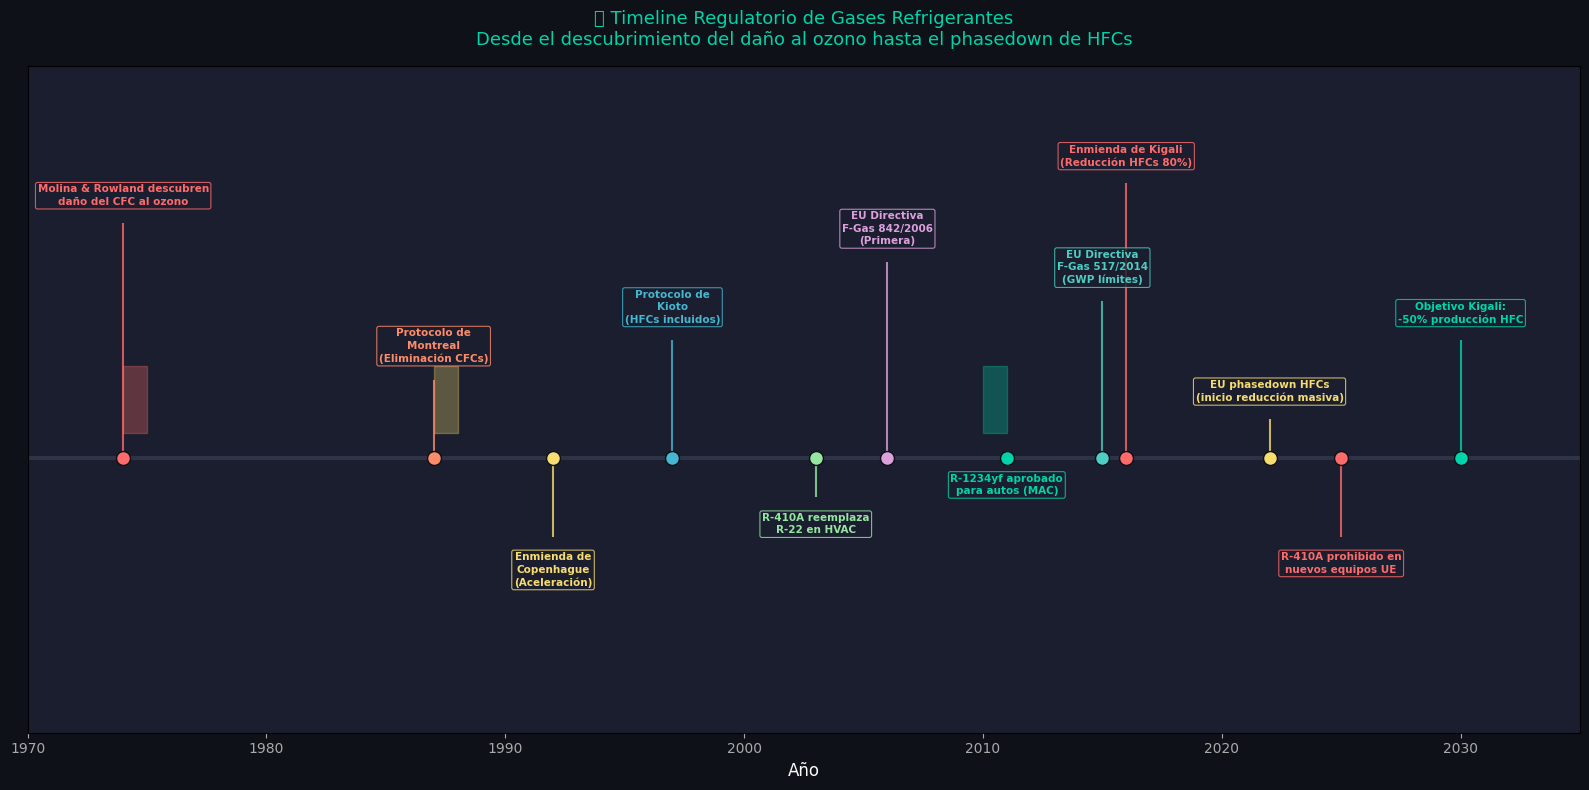

✅ Timeline regulatorio guardado.


In [5]:
# ============================================================
# BLOQUE 5: Timeline Regulatorio
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0E1117')

# Eventos regulatorios históricos
events = [
    (1974, 'Molina & Rowland descubren\ndaño del CFC al ozono', '#FF6B6B', 0.8),
    (1987, 'Protocolo de\nMontreal\n(Eliminación CFCs)', '#FF8C69', 0.6),
    (1992, 'Enmienda de\nCopenhague\n(Aceleración)', '#F7DC6F', 0.4),
    (1997, 'Protocolo de\nKioto\n(HFCs incluidos)', '#45B7D1', 0.65),
    (2003, 'R-410A reemplaza\nR-22 en HVAC', '#96E6A1', 0.45),
    (2006, 'EU Directiva\nF-Gas 842/2006\n(Primera)', '#DDA0DD', 0.75),
    (2011, 'R-1234yf aprobado\npara autos (MAC)', '#00D4AA', 0.5),
    (2015, 'EU Directiva\nF-Gas 517/2014\n(GWP límites)', '#4ECDC4', 0.7),
    (2016, 'Enmienda de Kigali\n(Reducción HFCs 80%)', '#FF6B6B', 0.85),
    (2022, 'EU phasedown HFCs\n(inicio reducción masiva)', '#F7DC6F', 0.55),
    (2025, 'R-410A prohibido en\nnuevos equipos UE', '#FF6B6B', 0.4),
    (2030, 'Objetivo Kigali:\n-50% producción HFC', '#00D4AA', 0.65),
]

# Dibujado de línea de tiempo
ax.axhline(0.5, color='#2E3347', linewidth=3, zorder=1)

for year, label, color, y_pos in events:
    # Línea vertical
    ax.vlines(year, 0.5, y_pos, color=color, linewidth=1.5, alpha=0.8, zorder=2)
    
    # Punto en el timeline
    ax.scatter(year, 0.5, s=100, color=color, zorder=5, edgecolors='#0E1117', linewidth=1)
    
    # Texto
    va = 'bottom' if y_pos > 0.5 else 'top'
    offset = 0.02 if y_pos > 0.5 else -0.02
    ax.text(year, y_pos + offset, label, fontsize=7.5, color=color,
            ha='center', va=va, fontweight='bold', linespacing=1.3,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#1A1E2E', alpha=0.8,
                      edgecolor=color, linewidth=0.8))

# Años de referencia en el eje
ax.set_xlim(1970, 2035)
ax.set_ylim(0.15, 1.0)
ax.set_yticks([])
ax.set_xlabel('Año', fontsize=12)
ax.set_title('📅 Timeline Regulatorio de Gases Refrigerantes\nDesde el descubrimiento del daño al ozono hasta el phasedown de HFCs',
             fontsize=13, color='#00D4AA', pad=15)

# Décadas sombreadas
for decade_start, color_shade in [(1974, '#FF6B6B'), (1987, '#F7DC6F'), (2010, '#00D4AA')]:
    ax.axvspan(decade_start, decade_start + 1, alpha=0.3, color=color_shade, ymin=0.45, ymax=0.55)

plt.tight_layout()
plt.savefig('../data/processed/regulatory_timeline.png', dpi=150,
            bbox_inches='tight', facecolor='#0E1117')
plt.show()
print('✅ Timeline regulatorio guardado.')

In [6]:
# ============================================================
# BLOQUE 6: Resumen de todas las visualizaciones generadas
# ============================================================
print('='*65)
print('📊 RESUMEN: VISUALIZACIONES PREMIUM GENERADAS')
print('='*65)

all_viz = [
    ('🌍 Mapa ambiental (GWP heatmap + scatter)', 'environmental_heatmap.png'),
    ('📈 Curvas P-T de saturación (10 gases clave)', 'pt_saturation_curves.png'),
    ('🫧 Diagrama de burbujas sostenibilidad', 'sustainability_bubble.png'),
    ('📅 Timeline regulatorio histórico', 'regulatory_timeline.png'),
    # Del notebook 02:
    ('📊 Distribuciones y asimetría', 'distributions_analysis.png'),
    ('🔗 Mapa de correlaciones (Spearman + Pearson)', 'correlation_analysis.png'),
    ('📦 Boxplot GWP por categoría (Kruskal-Wallis)', 'gwp_category_boxplot.png'),
    ('🔢 Biplot PCA', 'pca_analysis.png'),
    # Del notebook 03:
    ('📐 Elbow + Silhouette (K óptimo)', 'optimal_k_analysis.png'),
    ('🔍 K-Means vs Categorías Reales', 'clustering_visualization.png'),
    ('🔑 Feature Importance', 'feature_importance.png'),
    ('✅ Matriz de confusión', 'confusion_matrix.png'),
    ('🌳 Dendrograma jerárquico', 'dendrogram.png'),
]

for title, filename in all_viz:
    path = f'../data/processed/{filename}'
    exists = '✅' if os.path.exists(path) else '⏳ (ejecutar notebook)'
    print(f'  {exists}  {title}')
    if os.path.exists(path):
        size_kb = os.path.getsize(path) // 1024
        print(f'       📁 {filename} ({size_kb} KB)')

print(f'\n✨ {len(all_viz)} visualizaciones en total para el portfolio')

📊 RESUMEN: VISUALIZACIONES PREMIUM GENERADAS
  ✅  🌍 Mapa ambiental (GWP heatmap + scatter)
       📁 environmental_heatmap.png (157 KB)
  ✅  📈 Curvas P-T de saturación (10 gases clave)
       📁 pt_saturation_curves.png (289 KB)
  ✅  🫧 Diagrama de burbujas sostenibilidad
       📁 sustainability_bubble.png (131 KB)
  ✅  📅 Timeline regulatorio histórico
       📁 regulatory_timeline.png (124 KB)
  ✅  📊 Distribuciones y asimetría
       📁 distributions_analysis.png (172 KB)
  ✅  🔗 Mapa de correlaciones (Spearman + Pearson)
       📁 correlation_analysis.png (86 KB)
  ✅  📦 Boxplot GWP por categoría (Kruskal-Wallis)
       📁 gwp_category_boxplot.png (60 KB)
  ✅  🔢 Biplot PCA
       📁 pca_analysis.png (125 KB)
  ✅  📐 Elbow + Silhouette (K óptimo)
       📁 optimal_k_analysis.png (166 KB)
  ✅  🔍 K-Means vs Categorías Reales
       📁 clustering_visualization.png (109 KB)
  ✅  🔑 Feature Importance
       📁 feature_importance.png (50 KB)
  ✅  ✅ Matriz de confusión
       📁 confusion_matrix.png (48 KB